<a href="https://colab.research.google.com/github/Santatriniaina17/TP-ML-IGGLIA5/blob/Main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import matplotlib.pyplot as plt
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso

# Chargement du dataset
ds = sklearn.datasets.fetch_california_housing()
df = pd.DataFrame(ds.data, columns=ds.feature_names)

# Ajouter la variable cible
df['MedHouseVal'] = ds.target

# Affichage
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [27]:
# Vérifier les types de données
df.dtypes


,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [28]:
#EDA (Analyse Exploratoire des Données)
#Statistique descriptive
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


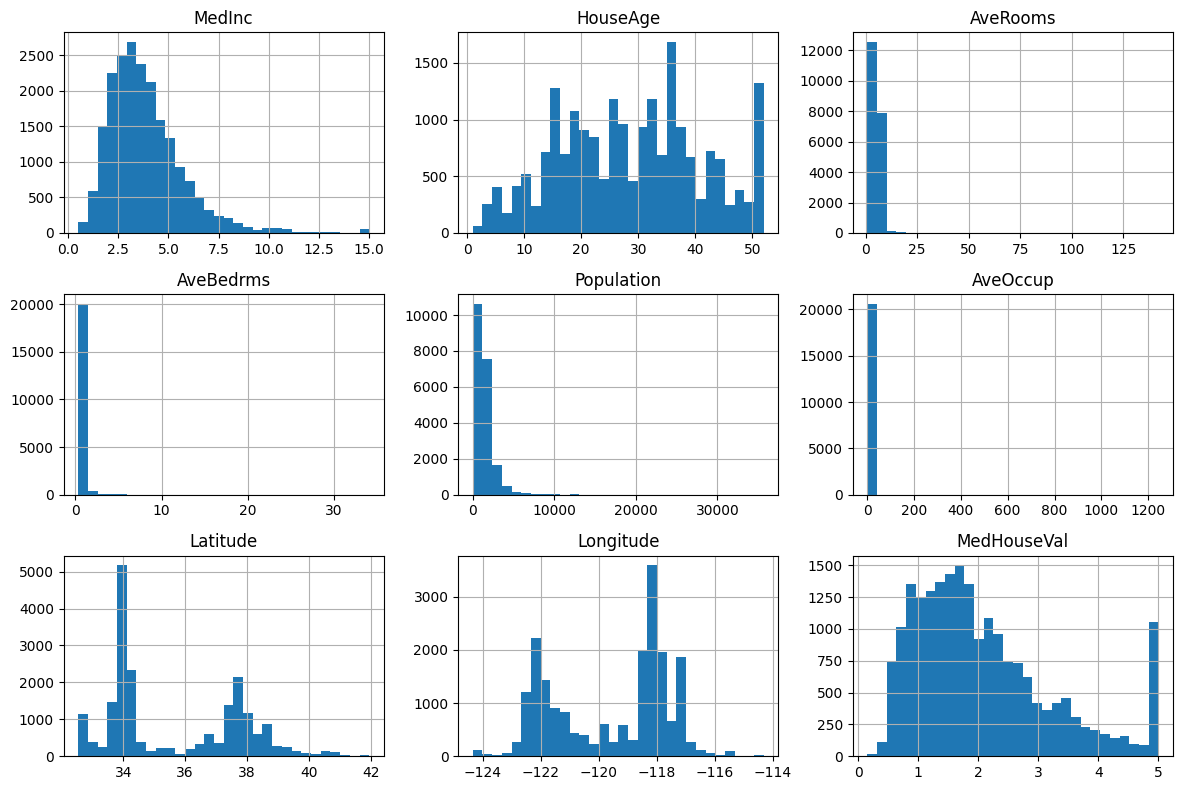

In [29]:
# Histogrammes
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

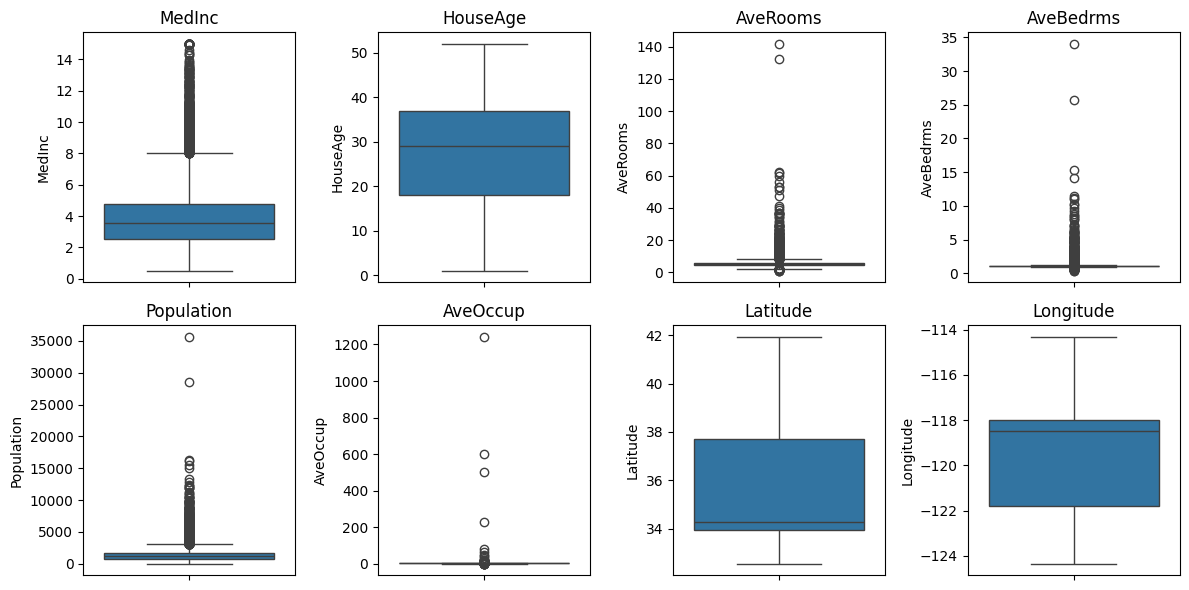

In [31]:
# Boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

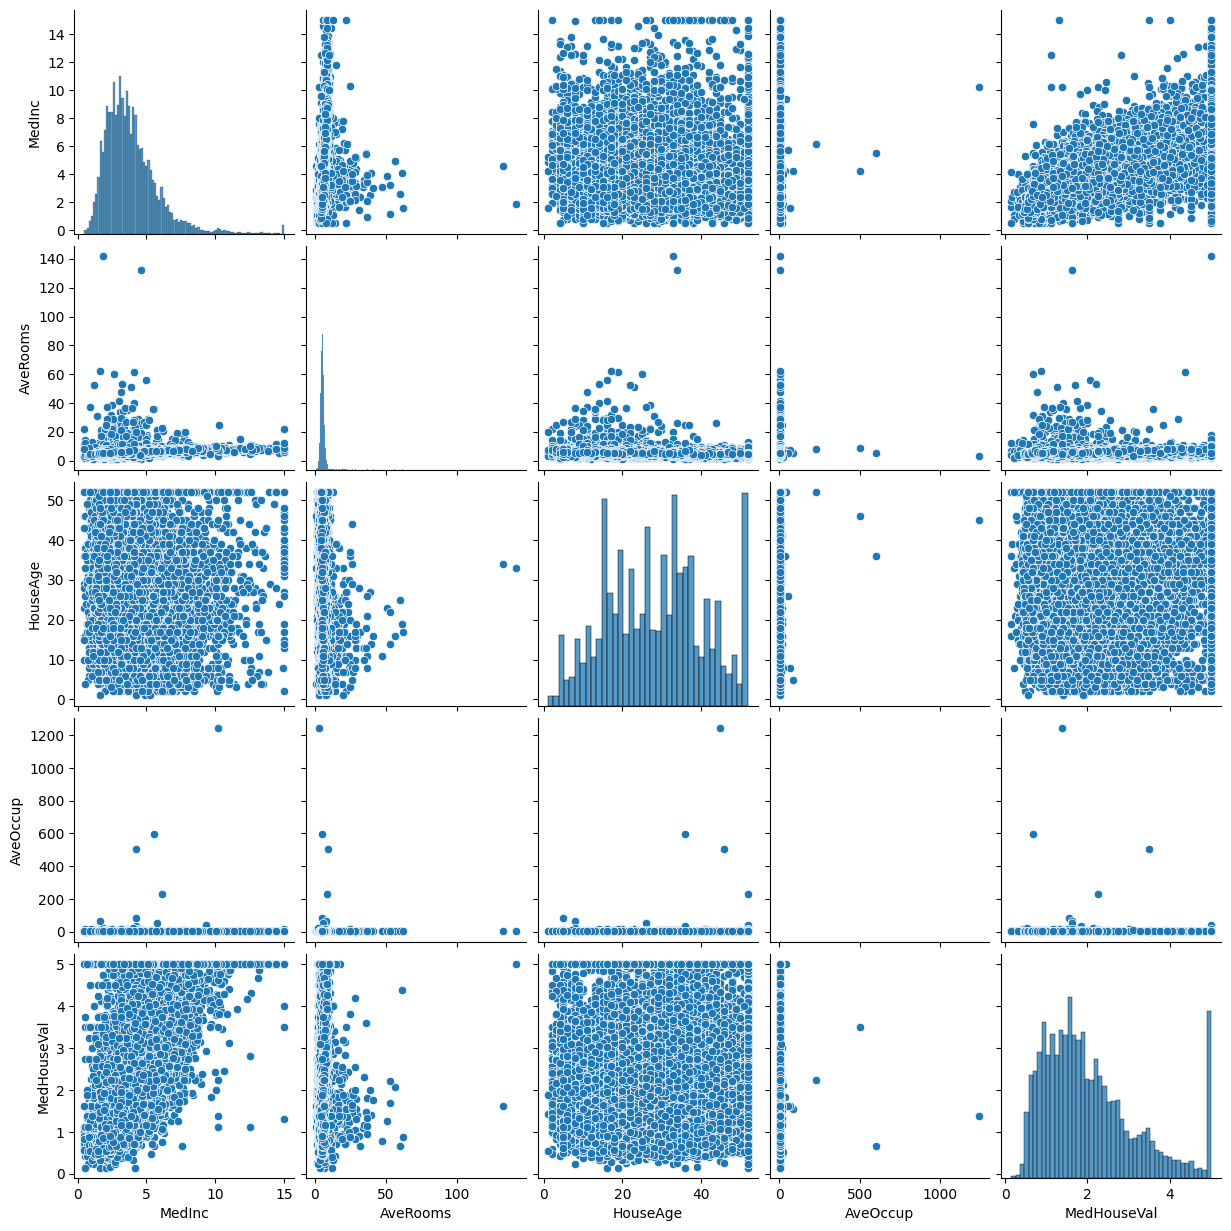

In [33]:
# Scatter plots (prix vs quelques variables)
sns.pairplot(df[['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', 'MedHouseVal']])
plt.show()

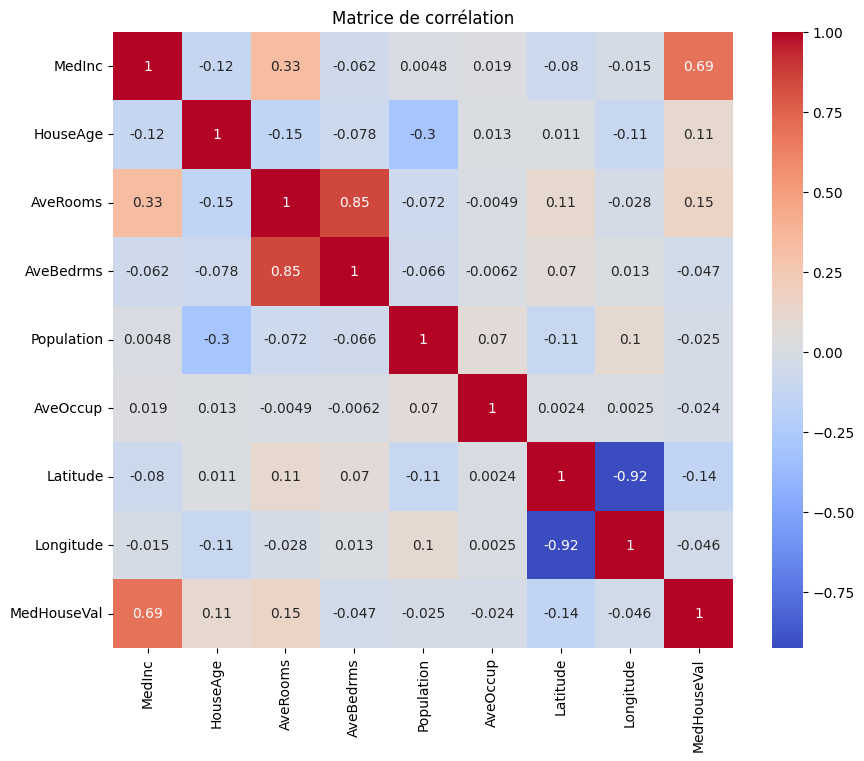

In [34]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [41]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#regression linéaire
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_val = lr.predict(X_val_scaled)

# Évaluation
print("MSE:", mean_squared_error(y_val, y_pred_val))
print("MAE:", mean_absolute_error(y_val, y_pred_val))
print("R²:", r2_score(y_val, y_pred_val))

MSE: 0.5325643962848101
MAE: 0.5336164161743362
R²: 0.5920099290350325


In [42]:
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_val_pred = ridge.predict(X_val_scaled)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_val_pred = lasso.predict(X_val_scaled)

# Comparaison
print("Ridge R²:", r2_score(y_val, ridge_val_pred))
print("Lasso R²:", r2_score(y_val, lasso_val_pred))

Ridge R²: 0.5920182746597593
Lasso R²: 0.4772146024913245


In [43]:
# Supposons que Ridge soit le meilleur
y_pred_test = ridge.predict(X_test_scaled)

print("MSE (test):", mean_squared_error(y_test, y_pred_test))
print("MAE (test):", mean_absolute_error(y_test, y_pred_test))
print("R² (test):", r2_score(y_test, y_pred_test))


MSE (test): 0.5545733931004739
MAE (test): 0.5337479409939055
R² (test): 0.5955342565680284


In [49]:


def bootstrap_ci(model, X, y, n_iterations=1000, alpha=0.05):
    scores = []
    n = len(X)
    for _ in range(n_iterations):
        indices = np.random.choice(n, n, replace=True)
        X_sample = X[indices]
        y_sample = y.iloc[indices]
        pred = model.predict(X_sample)
        scores.append(mean_squared_error(y_sample, pred))
    lower = np.percentile(scores, 100 * (alpha/2))
    upper = np.percentile(scores, 100 * (1 - alpha/2))
    return lower, upper

ci = bootstrap_ci(ridge, X_test_scaled, y_test)
print(f"95% CI pour le MSE sur test : {ci}")


95% CI pour le MSE sur test : (np.float64(0.5037273827784042), np.float64(0.6201606905114534))


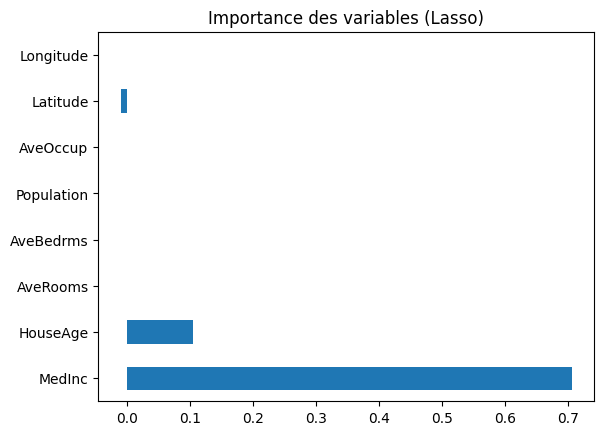

In [50]:
#Conclusion

coef = pd.Series(lasso.coef_, index=X.columns)
coef.plot(kind="barh", title="Importance des variables (Lasso)")
plt.show()


L’analyse menée à l’aide de la régression Lasso a permis de construire un modèle prédictif fiable du prix médian des maisons en Californie.
Grâce à la sélection automatique des variables, le modèle s’appuie uniquement sur les facteurs les plus pertinents, principalement :

    Le revenu médian (MedInc), qui est le facteur le plus influent.

    L’âge des maisons (HouseAge).

    Et dans une moindre mesure, la latitude.

Cette simplification améliore non seulement l’interprétabilité du modèle, mais aussi sa capacité à généraliser.
➤ Le modèle final peut ainsi prédire efficacement le prix médian des maisons sur des données nouvelles, tout en étant robuste et compréhensible.